In [1]:
!git clone https://github.com/Mahek-S/IndiUrbanClean-Dataset.git

Cloning into 'IndiUrbanClean-Dataset'...
remote: Enumerating objects: 1960, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 1960 (delta 2), reused 6 (delta 2), pack-reused 1954 (from 1)
Receiving objects: 100% (1960/1960), 1.10 GiB | 19.26 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Updating files: 100% (1990/1990), done.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import os
import time
import matplotlib.pyplot as plt
from torchvision.models import resnet50, ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
BASE_PATH = "IndiUrbanClean-Dataset"
IMG_PATH = os.path.join(BASE_PATH, "images")
SPLIT_PATH = os.path.join(BASE_PATH, "splits")

In [4]:
classes = ['clean_street', 'open_waste', 'construction_waste', 'dumpyard', 'overfilled_bins']
class_to_idx = {cls: i for i, cls in enumerate(classes)}

In [5]:
import pandas as pd

df = pd.read_csv("IndiUrbanClean-Dataset/splits/train.csv")
print(df.columns)
print(df.head())

Index(['image_id', 'filename', 'label'], dtype='object')
   image_id              filename         label
0         1  clean_street_096.jpg  clean_street
1         2  clean_street_310.jpg  clean_street
2         3  clean_street_061.jpg  clean_street
3         4  clean_street_318.jpg  clean_street
4         5  clean_street_056.jpg  clean_street


In [6]:
class UrbanWasteDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        img_name = row['filename']
        label = row['label']

        img_path = os.path.join(self.img_dir, label, img_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = class_to_idx[label]

        return image, label

In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [8]:
train_dataset = UrbanWasteDataset(
    os.path.join(SPLIT_PATH, "train.csv"),
    IMG_PATH,
    transform
)

val_dataset = UrbanWasteDataset(
    os.path.join(SPLIT_PATH, "val.csv"),
    IMG_PATH,
    transform
)

test_dataset = UrbanWasteDataset(
    os.path.join(SPLIT_PATH, "test.csv"),
    IMG_PATH,
    transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [9]:
def get_model(strategy):
    from torchvision.models import resnet18, ResNet18_Weights
    model = resnet18(weights=ResNet18_Weights.DEFAULT)

    # Freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    if strategy == "all_but_head":
        pass  # only head trains

    elif strategy == "freeze_early":
        # Unfreeze layer3, layer4 — freeze conv1, bn1, layer1, layer2
        for name, param in model.named_parameters():
            if name.startswith("layer3") or name.startswith("layer4"):
                param.requires_grad = True

    elif strategy == "freeze_late":
        # Unfreeze conv1, bn1, layer1, layer2 — freeze layer3, layer4
        for name, param in model.named_parameters():
            if (name.startswith("conv1") or
                name.startswith("bn1") or
                name.startswith("layer1") or
                name.startswith("layer2")):
                param.requires_grad = True

    elif strategy == "train_all":
        for param in model.parameters():
            param.requires_grad = True

    # Always replace and unfreeze head
    model.fc = nn.Linear(model.fc.in_features, 5)
    for param in model.fc.parameters():
        param.requires_grad = True

    return model.to(device)

In [17]:
def train_model(strategy, train_loader, val_loader, epochs=5):
    model = get_model(strategy)

    lr_map = {
    "all_but_head": 1e-3,
    "freeze_early": 1e-4,
    "freeze_late":  1e-4,
    "train_all":    1e-4,
    }

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr_map[strategy]
    )

    criterion = nn.CrossEntropyLoss()

    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # ── Training phase ──────────────────────────────
        model.train()
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total

        # ── Validation phase ─────────────────────────────
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

    return model, train_accs, val_accs


In [11]:
def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [12]:
strategies = ["all_but_head", "freeze_early", "freeze_late", "train_all"]

In [13]:
def check_frozen_layers(strategy):
    model = get_model(strategy)
    print(f"\n--- {strategy} ---")
    for name, param in model.named_parameters():
        print(f"{name}: requires_grad={param.requires_grad}")

for s in strategies:
    check_frozen_layers(s)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 200MB/s]



--- all_but_head ---
conv1.weight: requires_grad=False
bn1.weight: requires_grad=False
bn1.bias: requires_grad=False
layer1.0.conv1.weight: requires_grad=False
layer1.0.bn1.weight: requires_grad=False
layer1.0.bn1.bias: requires_grad=False
layer1.0.conv2.weight: requires_grad=False
layer1.0.bn2.weight: requires_grad=False
layer1.0.bn2.bias: requires_grad=False
layer1.1.conv1.weight: requires_grad=False
layer1.1.bn1.weight: requires_grad=False
layer1.1.bn1.bias: requires_grad=False
layer1.1.conv2.weight: requires_grad=False
layer1.1.bn2.weight: requires_grad=False
layer1.1.bn2.bias: requires_grad=False
layer2.0.conv1.weight: requires_grad=False
layer2.0.bn1.weight: requires_grad=False
layer2.0.bn1.bias: requires_grad=False
layer2.0.conv2.weight: requires_grad=False
layer2.0.bn2.weight: requires_grad=False
layer2.0.bn2.bias: requires_grad=False
layer2.0.downsample.0.weight: requires_grad=False
layer2.0.downsample.1.weight: requires_grad=False
layer2.0.downsample.1.bias: requires_grad=Fa

In [18]:
import time

strategies = ["all_but_head", "freeze_early", "freeze_late", "train_all"]
results = {}

for strategy in strategies:
    print(f"\n===== {strategy} =====")
    start = time.time()

    model, train_accs, val_accs = train_model(
        strategy, train_loader, val_loader, epochs=5
    )

    elapsed = time.time() - start
    test_acc = evaluate(model, test_loader)
    print(f"Test Accuracy: {test_acc:.4f}")

    results[strategy] = {
        "train_acc": train_accs[-1],
        "val_acc":   val_accs[-1],
        "test_acc":  test_acc,
        "time":      elapsed,
        "overfit":   train_accs[-1] - val_accs[-1],
        "train_curve": train_accs,
        "val_curve":   val_accs,
    }



===== all_but_head =====


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101756928 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 1: Train Acc=0.5795, Val Acc=0.8182
Epoch 2: Train Acc=0.8316, Val Acc=0.8754
Epoch 3: Train Acc=0.8627, Val Acc=0.8990
Epoch 4: Train Acc=0.8721, Val Acc=0.8956
Epoch 5: Train Acc=0.9061, Val Acc=0.9024
Test Accuracy: 0.8967

===== freeze_early =====
Epoch 1: Train Acc=0.8634, Val Acc=0.9562
Epoch 2: Train Acc=0.9921, Val Acc=0.9630
Epoch 3: Train Acc=0.9978, Val Acc=0.9596
Epoch 4: Train Acc=0.9957, Val Acc=0.9461
Epoch 5: Train Acc=0.9957, Val Acc=0.9495
Test Accuracy: 0.9233

===== freeze_late =====
Epoch 1: Train Acc=0.3071, Val Acc=0.5488
Epoch 2: Train Acc=0.7132, Val Acc=0.7576
Epoch 3: Train Acc=0.8569, Val Acc=0.8519
Epoch 4: Train Acc=0.9068, Val Acc=0.8586
Epoch 5: Train Acc=0.9393, Val Acc=0.8990
Test Accuracy: 0.8567

===== train_all =====
Epoch 1: Train Acc=0.8410, Val Acc=0.9562
Epoch 2: Train Acc=0.9892, Val Acc=0.9731
Epoch 3: Train Acc=0.9935, Val Acc=0.9562
Epoch 4: Train Acc=0.9957, Val Acc=0.9596
Epoch 5: Train Acc=0.9949, Val Acc=0.9562
Test Accuracy: 0.930

In [19]:
print("\nFINAL RESULTS TABLE")
print(f"{'Strategy':<16}{'Train':<10}{'Val':<10}{'Test':<10}{'Time':<12}{'Overfit':<10}")
for s, r in results.items():
    print(f"{s:<16}"
          f"{r['train_acc']:<10.4f}"
          f"{r['val_acc']:<10.4f}"
          f"{r['test_acc']:<10.4f}"
          f"{r['time']:<12.2f}"
          f"{r['overfit']:<10.4f}")


FINAL RESULTS TABLE
Strategy        Train     Val       Test      Time        Overfit   
all_but_head    0.9061    0.9024    0.8967    230.84      0.0037    
freeze_early    0.9957    0.9495    0.9233    234.78      0.0462    
freeze_late     0.9393    0.8990    0.8567    242.54      0.0403    
train_all       0.9949    0.9562    0.9300    246.62      0.0387    


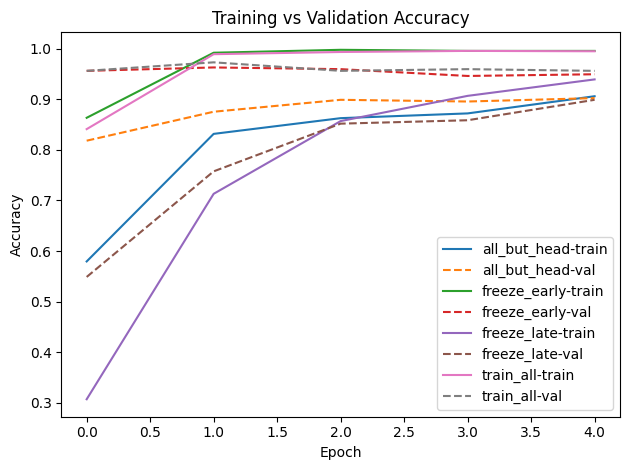

In [20]:
for strategy in strategies:
    plt.plot(results[strategy]['train_curve'], label=f"{strategy}-train")
    plt.plot(results[strategy]['val_curve'], linestyle='--', label=f"{strategy}-val")

plt.legend()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()